In [55]:
pip install -e ..

Obtaining file:///home/sagar/winogender_contextuality
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for winogender_contextuality (pyproject.toml) ... done
  Created wheel for winogender_contextuality: filename=winogender_contextuality-0.0.1-py3-none-any.whl size=3680 sha256=7eaeda3a55298dce1ac4d00ae011d0f0629bc206b66dd3eb3821d0ed21b9bdb9
  Stored in directory: /tmp/pip-ephem-wheel-cache-a6t0ikk2/wheels/f6/b9/38/03ac5a5ccd63b90faa34c1614fd3e708a9c34ab8edb44270e9
Successfully built winogender_contextuality
  Attempting uninstall: winogender_contextuality
    Found existing installation: winogender_contextuality 0.0.1
    Uninstalling winogender_contextuality-0.0.1:
      Successfully uninstalled winogender_contextuality-0.0.1
Note: you may need to restart the kernel to use updated packages.


In [56]:
from winogender_contextuality.utils import *
from winogender_contextuality.modeling.contextuality import *
from winogender_contextuality.config import * 

In [57]:
from matplotlib import pyplot as plt
import numpy as np
from collections import defaultdict, Counter
from tqdm.notebook import tqdm
import pandas as pd
from scipy import stats
from sklearn.metrics import log_loss, roc_auc_score
import statsmodels.formula.api as smf

# Data Loading

In [41]:
templates = pd.read_csv(RAW_DATA_DIR / "templates.tsv", sep='\t')

## Llama

In [42]:
# T = 0.5
llama32 = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.2-1B-Instruct_0.503.ndjson")
max_llama = max([d['index'] for d in llama32])

In [43]:
# T = 0.7
llama32_07 =load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Llama-3.2-1B-Instruct_0.703.ndjson")

In [44]:
# Neutral Pronouns
llama32_neutral = load_ndjson(INTERIM_DATA_DIR/"one_pronoun_measurements_Llama-3.2-1B-Instruct_0.5_1425050925.ndjson")

## Qwen

In [45]:
qwen15 = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Qwen1.5-0.5B-Chat_0.501.ndjson")
max_qwen = max([d['index'] for d in qwen15])

## GPT

In [46]:
gpt = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_gpt-oss-20b_0.5.ndjson")
max_gpt = max([d['index'] for d in gpt])

## Phi

In [47]:
phi = load_ndjson(INTERIM_DATA_DIR / "one_pronoun_measurements_Phi-4-mini-instruct_0.501.ndjson")
max_phi = max([d['index'] for d in phi])

# Average position with and without priming sentence (of each gender)

There are two options here 
1. My thought - 60 columns with a point for the unprimed distribution, a point for the male primed, and a point for the female primed. This would be for each model.
2. Andrea's thought--the average over all instances, varying by temperature

Either way, little distance distributions which go in the corner and then get put into illustrator to be shrinked down into cute lil drawings 

## Llama

### First Pronoun Bias

In [48]:
def order_bias(data: list[Measurement],
              max_index: int = 60,
              single_only: bool = False):

    minternal_probs = []
    mgeneration_probs = []
    finternal_probs = []
    fgeneration_probs = []

    for idx in range(max_index):
        all_index_data = get_index(idx, data)

        if single_only:
            all_data = get_single_sentences(all_index_data)
        else:
            all_data = all_index_data
            
        mfirst = [d for d in all_data if d['context']['pnoun_order'][1] == 0]
        ffirst = [d for d in all_data if d['context']['pnoun_order'][1] == 1]

        minternal = get_internal_probs(mfirst)
        mgeneration = get_generation_probs(mfirst)
        finternal = get_internal_probs(ffirst)
        fgeneration = get_generation_probs(ffirst)

        minternal_probs.append(minternal)
        mgeneration_probs.append(mgeneration)
        finternal_probs.append(finternal)
        fgeneration_probs.append(fgeneration)

    return minternal_probs, mgeneration_probs, finternal_probs, fgeneration_probs

In [49]:
llama_neutral_biases_single = order_bias(llama32_neutral, single_only=True)

/home/sagar/winogender_contextuality/winogender_contextuality/utils.py:239: RuntimeWarning: invalid value encountered in divide
  generation_probs = np.array(list(generation_counter_clean.values())) / num_valid_measurements


Text(0.5, 1.0, 'Internal Neopronoun Probability')

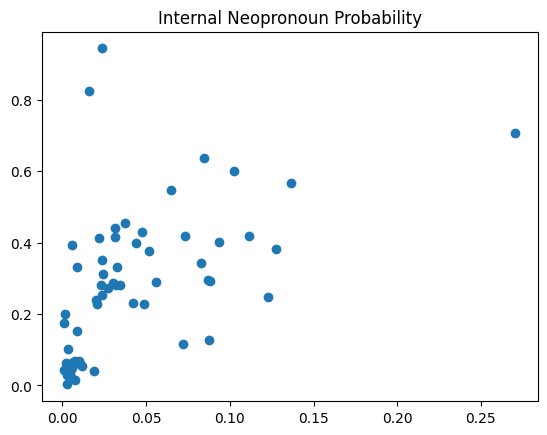

In [50]:
plt.scatter(
    [m[1] for m in llama_neutral_biases_single[0]],
    [m[1] for m in llama_neutral_biases_single[2]]
)
plt.title('Internal Neopronoun Probability')

Text(0.5, 1.0, 'Generation Neopronoun Probability')

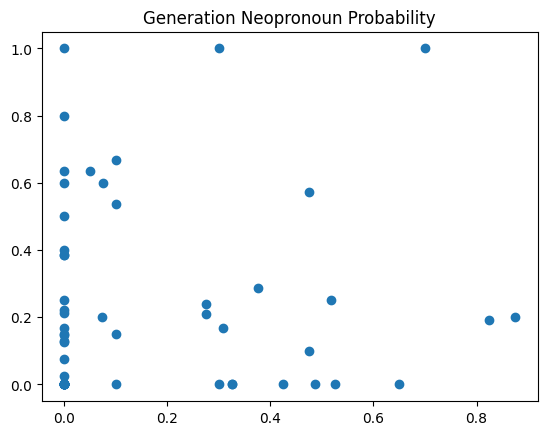

In [51]:
plt.scatter(
    [m[1] for m in llama_neutral_biases_single[1]],
    [m[1] for m in llama_neutral_biases_single[3]]
)
plt.title('Generation Neopronoun Probability')

### Primed Completion Differences

In [52]:
def primed_completion_differences(data: list[Measurement],
                                  mode: str,
                                  max_index: int = 60,
                                  plot: bool = False):
    """
    Plots the probability of female pronoun generation for each sentence pair and its reverse.

    :param data: list of Measurement objects (or equivalently structured dictionaries)
    :param mode: 'internal' or 'generation'
    :param max_index: maximum index in data (last index is thrown away)
    :param plot: whether to plot results

    :returns: list of tuples with (unprimed fpronoun prob, mprimed fpronoun production prob, fprimed fpronoun production prob)
    """

    differences = []

    if mode == 'internal':
        prob_func = get_internal_probs
    elif mode == 'generation':
        prob_func = get_generation_probs
    else:
        raise AttributeError

    for idx in tqdm(range(max_index)):
        all_index_data = get_index(idx, data)

        unprimed_1 = prob_func(get_sent_order([0, 1], get_single_sentences(all_index_data)))
        unprimed_2 = prob_func(get_sent_order([1, 0], get_single_sentences(all_index_data)))

        primed_m1 = prob_func(get_sent_order([0, 1], get_filled_pnoun(0, all_index_data)))
        primed_f1 = prob_func(get_sent_order([0, 1], get_filled_pnoun(1, all_index_data)))
        primed_m2 = prob_func(get_sent_order([1, 0], get_filled_pnoun(0, all_index_data)))
        primed_f2 = prob_func(get_sent_order([1, 0], get_filled_pnoun(1, all_index_data)))

        tup1 = (unprimed_1, primed_m1, primed_f1)
        tup2 = (unprimed_2, primed_m2, primed_f2)

        try: 
            differences.append(tup1)
            differences.append(tup2)
        except ValueError:
            print(tup1, tup2)

    def is_valid_tuple(tup):
        return not any(np.isnan(arr).any() for arr in tup)

    if plot:
        fig, ax = plt.subplots(figsize=(10, 4))
        pruned_differences = [(n,t) for n,t in enumerate(differences) if is_valid_tuple(t)]
        collected_indices = [p[0] for p in pruned_differences]
        
        ax.plot(collected_indices, [p[1][0][1] for p in pruned_differences], label='unprimed', marker='x',
                linestyle='None', color='gray',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][1][1] for p in pruned_differences], label='m primed', marker='o',
                linestyle='None', color='#E69F00',
                markersize=5)
        
        ax.plot(collected_indices, [p[1][2][1] for p in pruned_differences], label='f primed', marker='o',
                linestyle='None', color='#009E73',
                markersize=5)
            
        ax.legend()
        
        for subidx in collected_indices:
            try:
                min_idx, med_idx, max_idx = np.argsort([i[1] for i in differences[subidx]])
            except IndexError:
                continue

            if med_idx != 0:
                color = 'red'
            elif min_idx != 2:
                color = '#0072B2'
            else:
                color = 'gray'
                
            lb = differences[subidx][min_idx][1]
            ub = differences[subidx][max_idx][1]
            ax.vlines(subidx, ymin=lb, ymax=ub, alpha=0.5, color=color, linewidth=0.7)

        ax.set_xticks([])

    return differences

  0%|          | 0/60 [00:00<?, ?it/s]

/home/sagar/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sagar/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


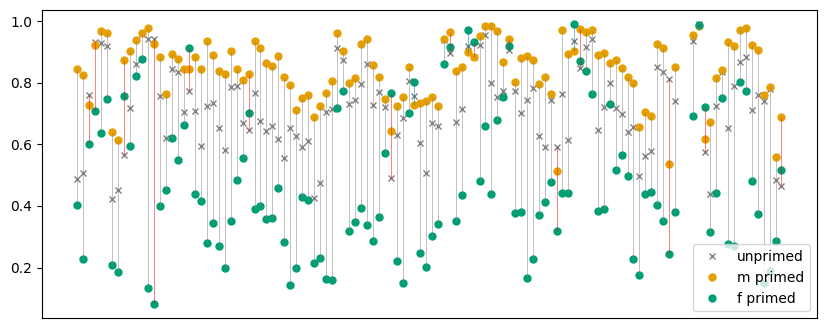

In [53]:
int_llama_neutral_prim_diffs = primed_completion_differences(llama32, 'internal', plot=True)

In [58]:
gen_llama_neutral_prim_diffs = primed_completion_differences(llama32, 'generation', plot=True)

  0%|          | 0/60 [00:00<?, ?it/s]

2025-09-06 17:29:50.969 | DEBUG    | winogender_contextuality.utils:get_generation_probs:227 - No measurements found.


UnboundLocalError: cannot access local variable 'pnouns' where it is not associated with a value

### Mean Shifts

In [ ]:
def mean_completion_shift(data: list[Measurement] | list[tuple],
                          mode: str | None = None,
                          max_index: int = 60):

    """
    Calculates the mean shift (across all ordered sentences pairs) in the probability of female pronoun production for
    mprimed and fprimed sentences. 

    :param data: list of Measurement objects (or equivalently structured dictionaries) OR 
         list of tuples from primed_completion_differences()
    :param mode: 'internal' or 'generation' (only necessary if data is a list of dicts/Measurements)
    :param max_index: maximum index in data (last index is thrown away)

    :returns: (mean shift mprimed, mean shift fprimed, array of shifts with mprimed, array of shifts with fprimed)
    
    """

    if isinstance(data[0], dict) or isinstance(data[0], Measurement):
        if mode is None:
            raise AttributeError("Must define mode if data is not a list of probability tupes")
        else:
            tuples = primed_completion_differences(data, mode, max_index, plot=False)
    else:
        tuples = data

    unprimed_fprobs = np.array([t[0][1] for t in tuples])
    mprimed_fprobs = np.array([t[1][1] for t in tuples])
    fprimed_fprobs = np.array([t[2][1] for t in tuples])

    mshift = mprimed_fprobs - unprimed_fprobs
    fshift = fprimed_fprobs - unprimed_fprobs

    mean_mshift = np.nanmean(mshift)
    mean_fshift = np.nanmean(fshift)
    
    return mean_mshift, mean_fshift, mshift, fshift

In [ ]:
int_llama32_shifts = mean_completion_shift(int_llama_neutral_prim_diffs)
gen_llama32_shifts = mean_completion_shift(gen_llama_neutral_prim_diffs)

In [ ]:
int_llama32_shifts[:2], gen_llama32_shifts[:2]

In [ ]:
int_llama32_07_shifts = mean_completion_shift(llama32_07, mode='internal')
gen_llama32_07_shifts = mean_completion_shift(llama32_07, mode='generation')

In [ ]:
plt.plot([gen_llama32_shifts[0], gen_llama32_07_shifts[0]], label='mpronoun', marker='x')
plt.plot([gen_llama32_shifts[1], gen_llama32_07_shifts[1]], label='fpronoun', marker='o')
plt.legend()

### Does it Depend on Occupation?

In [ ]:
# ref_role, other_role
# {index: {forward: (ref_role, other_role), reverse: (ref_role, other_role)}}

pnoun_role_dict = defaultdict(dict)
for idx in range(max_llama):

    forward_sentence_idx = int((2 * idx) + 1)
    reverse_sentence_idx = int(2 * idx)

    answer_mapping = {0: 'occupation(0)', 1: 'other-participant(1)'}

    forward_ref_col = answer_mapping[templates['answer'][forward_sentence_idx]]
    forward_other_col = answer_mapping[(templates['answer'][forward_sentence_idx] + 1) % 2]
    reverse_ref_col = answer_mapping[templates['answer'][reverse_sentence_idx]]
    reverse_other_col = answer_mapping[(templates['answer'][reverse_sentence_idx] + 1) % 2]

    pnoun_role_dict[idx]['forward'] = (templates[forward_ref_col][forward_sentence_idx], templates[forward_other_col][forward_sentence_idx])
    pnoun_role_dict[idx]['reverse'] = (templates[reverse_ref_col][reverse_sentence_idx], templates[reverse_other_col][reverse_sentence_idx])

$$\operatorname{logit} P(X=1)=β_0 + β_O \cdot O + β_{P1} \cdot \mathbf{1}_{[Pr=m]}+β_{P2} \cdot \mathbf{1}_{[Pr=f]}$$

In [ ]:
# Creating a df for the first index, only generation
# X, O, P

# THIS IS INCORRECT - THIS IS COMBINING BOTH.. SHOULD BE TWO SEPERATE.. or should it.. given the roles as a variable..

test_list_fwd = get_sent_order([0,1],get_index(0,llama32))
test_list_bwd = get_sent_order([1,0],get_index(0,llama32))
#test_list_fwd

forward_occ = pnoun_role_dict.get(0)['forward'][0]
reverse_occ = pnoun_role_dict.get(0)['reverse'][0]

forward_prime_list = [str(m['context']['pnoun_order'][0]) for m in test_list_fwd]
backward_prime_list = [str(m['context']['pnoun_order'][0]) for m in test_list_bwd]

fwd_measurement_list = [m['measurement']['BLANK'] for m in test_list_fwd if m['measurement']['BLANK'] is not None]
bwd_measurement_list = [m['measurement']['BLANK'] for m in test_list_bwd if m['measurement']['BLANK'] is not None]

fwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in test_list_fwd]
bwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in test_list_bwd]

llama_measurements_df = pd.DataFrame(data={
    'Measurement': fwd_measurement_list + bwd_measurement_list, 
    'Role': [forward_occ] * len(test_list_fwd) + [reverse_occ]*len(test_list_bwd),
    'GPrime': forward_prime_list + backward_prime_list,
    'POrder': fwd_measurement_pnoun_order + bwd_measurement_pnoun_order
})

llama_measurements_df["X"] = (llama_measurements_df["Measurement"] == "she").astype(int)

In [ ]:
def create_regression_table(data: list[Measurement] | list[dict]):

    """
    Creates a DataFrame with columns [Measurement, Role, GPrime, POrder] for each *pair of sentences* using measurements provided. 

    :param data: List of Measurements (or equivalent dictionaries) 

    """

    fwd_list = get_sent_order([0,1],get_index(0,data, filter_none=True))
    bwd_list = get_sent_order([1,0],get_index(0,data, filter_none=True))

    forward_occ = pnoun_role_dict.get(0)['forward'][0]
    reverse_occ = pnoun_role_dict.get(0)['reverse'][0]

    fwd_prime_list = [str(m['context']['pnoun_order'][0]) for m in fwd_list]
    bwd_prime_list = [str(m['context']['pnoun_order'][0]) for m in bwd_list]

    fwd_measurement_list = [m['measurement']['BLANK'] for m in fwd_list if m['measurement']['BLANK'] is not None]
    bwd_measurement_list = [m['measurement']['BLANK'] for m in bwd_list if m['measurement']['BLANK'] is not None]

    fwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in fwd_list]
    bwd_measurement_pnoun_order = [str(m['context']['pnoun_order'][1]) for m in bwd_list]

    measurements_df = pd.DataFrame(data={
    'Measurement': fwd_list + bwd_list, 
    'Role': [forward_occ] * len(fwd_list) + [reverse_occ]*len(bwd_list),
    'GPrime': fwd_prime_list + bwd_prime_list,
    'POrder': fwd_measurement_pnoun_order + bwd_measurement_pnoun_order
    })

    measurements_df["X"] = (measurements_df["Measurement"] == "she").astype(int)

    return measurements_df
    
    

In [ ]:
def or_table(model):
    ci = model.conf_int()
    or_df = pd.DataFrame({
        "OR": np.exp(model.params),
        "CI_low": np.exp(ci[0]),
        "CI_high": np.exp(ci[1]),
        "p": model.pvalues
    })
    return or_df

In [ ]:
def lrt(m_reduced, m_full):
    LR = 2 * (m_full.llf - m_reduced.llf)
    df = m_full.df_model - m_reduced.df_model
    p = stats.chi2.sf(LR, df)
    return {"LR": LR, "df": df, "p": p}

In [ ]:
def metrics(model, data):
    p = model.predict(data)
    return {
        "log_loss": log_loss(data["X"], p, labels=[0, 1]),
        "AUC": roc_auc_score(data["X"], p)
    }

#### With Order

In [ ]:
formula_main_wo = "X ~ Role + C(GPrime, Treatment('None')) + C(POrder)"

In [ ]:
m_full_wo = smf.logit(formula_main_wo, data=llama_measurements_df).fit(disp=False)

In [ ]:
# Odds Ratio
or_main_wo = or_table(m_full_wo)
or_main_wo

In [ ]:
# Ablated Logit Models
m_noO_wo = smf.logit("X ~ C(GPrime, Treatment('None')) + C(POrder)", data=llama_measurements_df).fit(disp=False)
m_noP_wo = smf.logit("X ~ Role + C(POrder)", data=llama_measurements_df).fit(disp=False)
m_noPn_wo = smf.logit("X ~ Role + C(GPrime, Treatment('None'))", data=llama_measurements_df).fit(disp=False)

In [ ]:
# Likelihood Ratios
lrt_O_wo = lrt(m_noO_wo, m_full_wo) 
lrt_P_wo = lrt(m_noP_wo, m_full_wo)  
lrt_Pn_wo = lrt(m_noPn_wo, m_full_wo)  

In [ ]:
lrt_O_wo, lrt_P_wo, lrt_Pn_wo

In [ ]:
metrics_full_wo = metrics(m_full_wo, llama_measurements_df)
metrics_noO_wo  = metrics(m_noO_wo,  llama_measurements_df)  
metrics_noP_wo  = metrics(m_noP_wo,  llama_measurements_df)  
metrics_noPn_wo  = metrics(m_noPn_wo,  llama_measurements_df)  

In [ ]:
metrics_full_wo, metrics_noO_wo, metrics_noP_wo, metrics_noPn_wo

#### Analysis Without Order

In [ ]:
formula_main_no = "X ~ Role + C(GPrime, Treatment('None'))"

In [ ]:
m_full_no = smf.logit(formula_main_wo, data=llama_measurements_df).fit(disp=False)

In [ ]:
# Odds Ratio
or_main_no = or_table(m_full_no)
or_main_no

In [ ]:
# Ablated Logit Models
m_noO_no = smf.logit("X ~ C(GPrime, Treatment('None'))", data=llama_measurements_df).fit(disp=False)
m_noP_no = smf.logit("X ~ Role", data=llama_measurements_df).fit(disp=False)

In [ ]:
# Likelihood Ratios
lrt_O_no = lrt(m_noO_no, m_full_no) 
lrt_P_no = lrt(m_noP_no, m_full_no)  
lrt_O_no, lrt_P_no

In [ ]:
# ML Metrics
metrics_full_no = metrics(m_full_no, llama_measurements_df)
metrics_noO_no  = metrics(m_noO_no,  llama_measurements_df)  
metrics_noP_no  = metrics(m_noP_no,  llama_measurements_df) 

## Qwen 1.5

### Primed Completion Differences

In [ ]:
int_qwen_neutral_prim_diffs = primed_completion_differences(qwen15, 'internal', plot=True)

In [ ]:
gen_qwen_neutral_prim_diffs = primed_completion_differences(qwen15, 'generation', plot=True)

### Mean Shifts

In [ ]:
int_qwen15_shifts = mean_completion_shift(int_qwen_neutral_prim_diffs)
gen_qwen15_shifts = mean_completion_shift(gen_qwen_neutral_prim_diffs)

In [ ]:
int_qwen15_shifts[:2], gen_qwen15_shifts[:2]

### Does it Depend on Occuptation?

In [ ]:
qwen_measurement_df = create_regression_table(qwen15)

In [ ]:
m_full_wo = smf.logit(formula_main_wo, data=qwen_measurement_df).fit(disp=False)

## Phi 4

### Primed Completion Differences

In [ ]:
int_phi_neutral_prim_diffs = primed_completion_differences(phi, 'internal', plot=True)

In [ ]:
gen_phi_neutral_prim_diffs = primed_completion_differences(phi, 'generation', plot=True)

### Mean Shifts

### Does it Depend on Occupation

## GPT 

### Primed Completion Differences

In [ ]:
int_gpt_neutral_prim_diffs = primed_completion_differences(gpt, 'internal', plot=True)

In [ ]:
gen_gpt_neutral_prim_diffs = primed_completion_differences(gpt, 'generation', plot=True)

### Mean Shifts

### Does it Depend on Occupation?